# Evaluating if decision trees are better suited for an IDS than logistic regression

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, fbeta_score, accuracy_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import math

RANDOM_STATE = 5
np.random.seed(RANDOM_STATE)

## Scaling
Per-feature: log1p for the heavy-tailed byte columns, standardise the rest.

In [8]:
def fit_scaler(X, std_cols):
    mean = X[std_cols].mean()
    std  = np.clip(X[std_cols].std(), 1e-7, None)
    return mean, std

def apply_scaler(X, mean, std, std_cols, log_cols):
    scaled = X.copy()
    scaled[std_cols] = (X[std_cols] - mean) / std
    scaled[log_cols] = np.log1p(X[log_cols])
    return scaled

## Evaluation helper

In [16]:
def evaluate(preds, y, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    print(f"--- {title} ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=["normal", "anomaly"]))
    print(f"F2-score: {fbeta_score(y, preds, beta=2):.4f}\n")
    cm = confusion_matrix(y, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["normal", "anomaly"]).plot()
    plt.title(title)
    return preds

Load & Encode NSL-KDD data

LabelEncoder fitted on train, applied to test. one-hot encoding applied to 'service' column.

In [5]:
train_data, _ = arff.loadarff('data/KDDTrain+.arff')
test_data, _ = arff.loadarff('data/KDDTest+.arff')
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

# Decode bytes
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')

# Encode class column
cats = ['normal', 'anomaly']  # index 0 = normal, index 1 = anomaly
train_class    = pd.Categorical(df['class'], categories=cats).codes
test_class      = pd.Categorical(test_df['class'], categories=cats).codes

# one-hot encode categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohe.fit(df[categorical_cols])

train_one_hot = ohe.transform(df[categorical_cols]); test_one_hot = ohe.transform(test_df[categorical_cols])
df = df.drop(categorical_cols + ['class'], axis=1)
test_df = test_df.drop(categorical_cols + ['class'], axis=1)

# Scale numeric columns
log_cols = ['src_bytes', 'dst_bytes']
standard_cols = [c for c in df.columns if c not in log_cols + ['class']]
df[standard_cols] = df[standard_cols].apply(pd.to_numeric, errors='coerce')
test_df[standard_cols] = test_df[standard_cols].apply(pd.to_numeric, errors='coerce')
mean, std = fit_scaler(df, standard_cols)
scaled_num_train_X = apply_scaler(df, mean, std, standard_cols, log_cols)
scaled_num_test_X  = apply_scaler(test_df, mean, std, standard_cols, log_cols)

# training sets below currently hold only numeric columns
train_X = df.to_numpy(dtype=float)
train_y = train_class
test_X = test_df.to_numpy(dtype=float)
test_y = test_class

# Stick one-hot encoded categorical columns back onto the numeric (scaled) columns
scaled_train_X = np.hstack((scaled_num_train_X, train_one_hot))
scaled_test_X  = np.hstack((scaled_num_test_X, test_one_hot))

# Take 20% of training set to form cross validation set
scaled_train_X, cv_X, train_y, cv_y = train_test_split(
    scaled_train_X, train_y, test_size=0.2, stratify=train_y, random_state=0
)

## Decision Tree
First we will train a single decision tree. We will tune two hyper-parameters:
- minimum samples to allow a further split;
- maximum tree depth.

In [11]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

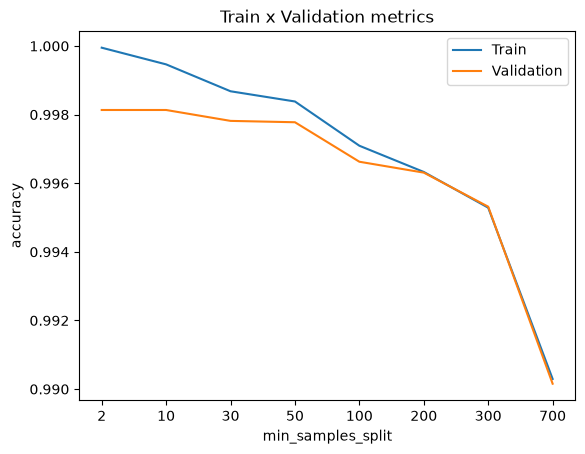

In [12]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(scaled_train_X,train_y) 
    predictions_train = model.predict(scaled_train_X) ## The predicted values for the train dataset
    predictions_val = model.predict(cv_X) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,train_y)
    accuracy_val = accuracy_score(predictions_val,cv_y)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

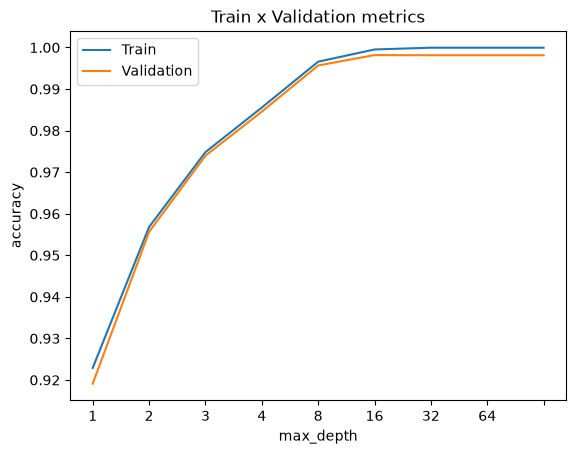

In [13]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(scaled_train_X,train_y) 
    predictions_train = model.predict(scaled_train_X) ## The predicted values for the train dataset
    predictions_val = model.predict(cv_X) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,train_y)
    accuracy_val = accuracy_score(predictions_val,cv_y)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

For this dataset, we see increasing the min_samples_split leads to lower train and CV accuracies, with the opposite true for max_depth. A very much aligned CV and train accuracy with these hyper-paramters is aligned with the results from logistic regression. In an attempt to keep overfitting low, I will select the following values for these hyper-parameters:
- `max_depth = 4`
- `min_samples_split = 200`

--- DEC TREE TRAIN ---
accuracy: 0.9856
              precision    recall  f1-score   support

      normal       0.98      0.99      0.99     53874
     anomaly       0.99      0.98      0.98     46904

    accuracy                           0.99    100778
   macro avg       0.99      0.99      0.99    100778
weighted avg       0.99      0.99      0.99    100778

F2-score: 0.9802

--- DEC TREE TEST ---
accuracy: 0.8164
              precision    recall  f1-score   support

      normal       0.71      0.97      0.82      9711
     anomaly       0.97      0.70      0.81     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.83      0.82     22544
weighted avg       0.86      0.82      0.82     22544

F2-score: 0.7423



array([1, 1, 0, ..., 1, 0, 1], shape=(22544,), dtype=int8)

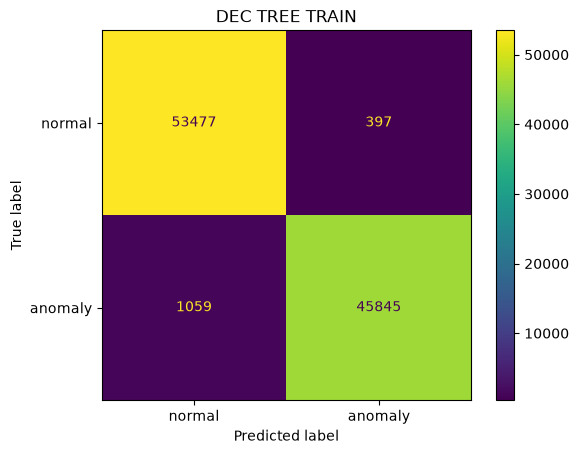

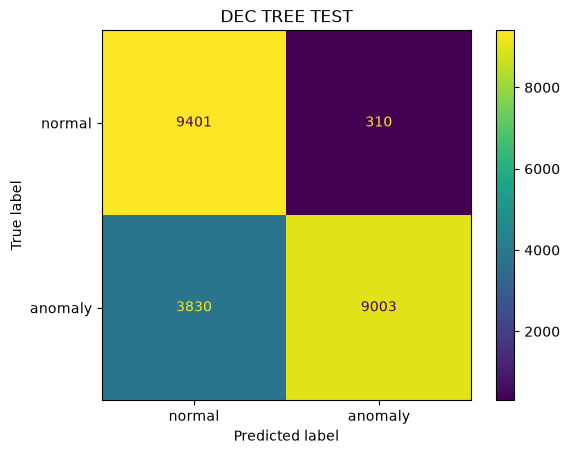

In [17]:
model = DecisionTreeClassifier(max_depth = 4,
                               min_samples_split = 200,
                               random_state = RANDOM_STATE).fit(scaled_train_X, train_y)
evaluate(model.predict(scaled_train_X), train_y, title="DEC TREE TRAIN")
evaluate(model.predict(scaled_test_X), test_y, title="DEC TREE TEST")

## Random Forest
Secondly, we will train a random forest model. We will tune for the same two previous hyper-paramaters, along with the new number of estimators. {FUTURE ME: use GridSearchCV instead!}

In [23]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

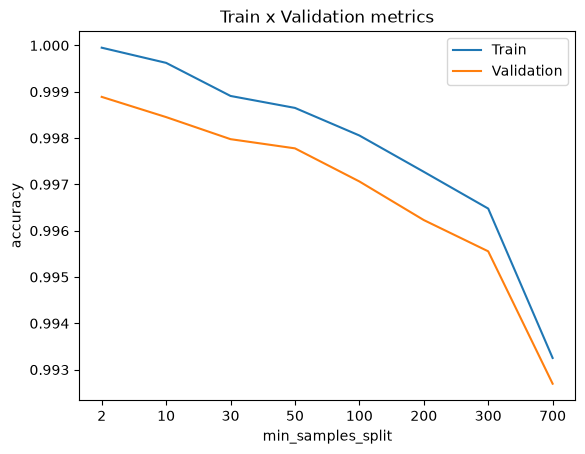

In [19]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(scaled_train_X,train_y) 
    predictions_train = model.predict(scaled_train_X) ## The predicted values for the train dataset
    predictions_val = model.predict(cv_X) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,train_y)
    accuracy_val = accuracy_score(predictions_val,cv_y)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

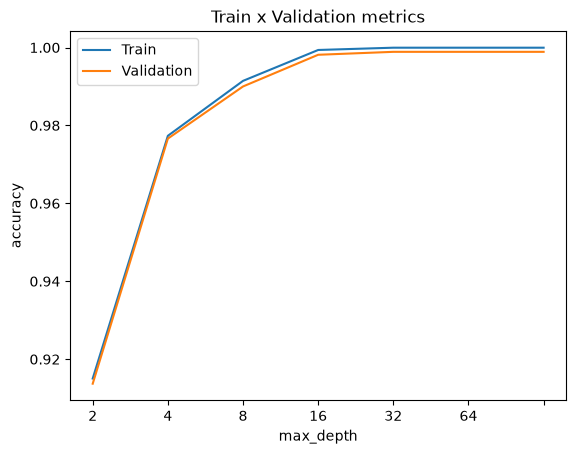

In [20]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(scaled_train_X,train_y) 
    predictions_train = model.predict(scaled_train_X) ## The predicted values for the train dataset
    predictions_val = model.predict(cv_X) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,train_y)
    accuracy_val = accuracy_score(predictions_val,cv_y)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

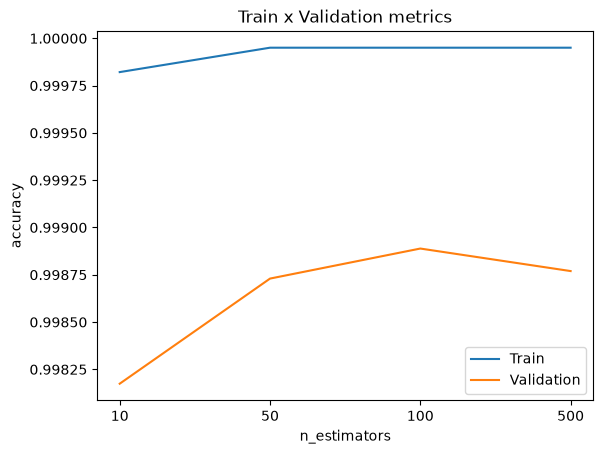

In [25]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(scaled_train_X,train_y) 
    predictions_train = model.predict(scaled_train_X) ## The predicted values for the train dataset
    predictions_val = model.predict(cv_X) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,train_y)
    accuracy_val = accuracy_score(predictions_val,cv_y)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list)),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

Let's then fit a random forest with the following parameters:

 - max_depth: 16
 - min_samples_split: 700 (train and CV cost begin to converge)
 - n_estimators: 100

--- RANDOM FOREST TRAIN ---
accuracy: 0.9934
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     53874
     anomaly       1.00      0.99      0.99     46904

    accuracy                           0.99    100778
   macro avg       0.99      0.99      0.99    100778
weighted avg       0.99      0.99      0.99    100778

F2-score: 0.9895

--- RANDOM FOREST TEST ---
accuracy: 0.7593
              precision    recall  f1-score   support

      normal       0.65      0.97      0.78      9711
     anomaly       0.97      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544

F2-score: 0.6477



array([1, 1, 0, ..., 1, 0, 1], shape=(22544,), dtype=int8)

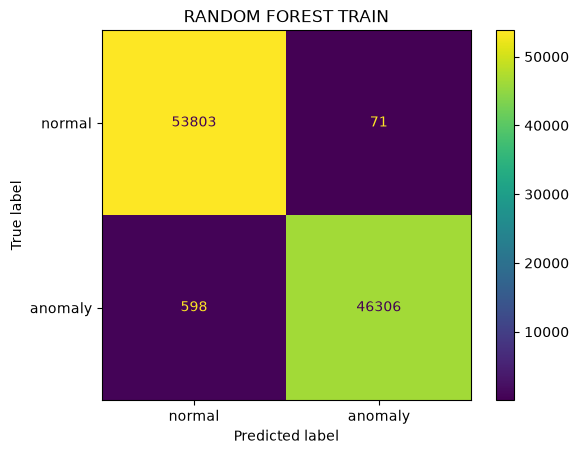

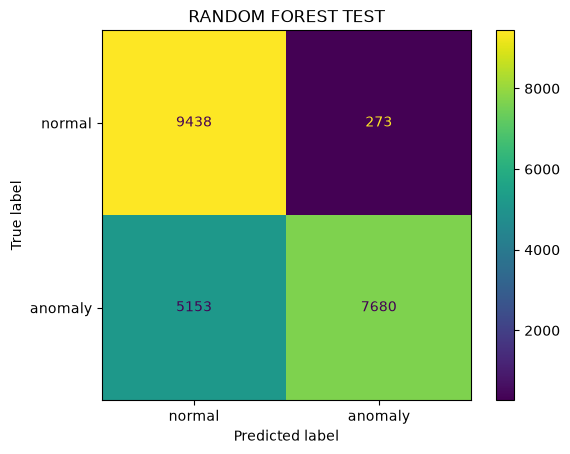

In [26]:
model = RandomForestClassifier(max_depth = 16,
                               min_samples_split = 700,
                               n_estimators = 100,
                               random_state = RANDOM_STATE).fit(scaled_train_X, train_y)
evaluate(model.predict(scaled_train_X), train_y, title="RANDOM FOREST TRAIN")
evaluate(model.predict(scaled_test_X), test_y, title="RANDOM FOREST TEST")

## XGBoost
Finally, we will train an XGBoost ensemble.

In [31]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,  early_stopping_rounds=10)
xgb_model.fit(scaled_train_X,train_y, eval_set = [(cv_X,cv_y)])

[0]	validation_0-logloss:0.59825
[1]	validation_0-logloss:0.52261
[2]	validation_0-logloss:0.45987
[3]	validation_0-logloss:0.40651
[4]	validation_0-logloss:0.36082
[5]	validation_0-logloss:0.32159
[6]	validation_0-logloss:0.28775
[7]	validation_0-logloss:0.25799
[8]	validation_0-logloss:0.23219
[9]	validation_0-logloss:0.20928
[10]	validation_0-logloss:0.18937
[11]	validation_0-logloss:0.17135
[12]	validation_0-logloss:0.15552
[13]	validation_0-logloss:0.14131
[14]	validation_0-logloss:0.12798
[15]	validation_0-logloss:0.11623
[16]	validation_0-logloss:0.10575
[17]	validation_0-logloss:0.09635
[18]	validation_0-logloss:0.08820
[19]	validation_0-logloss:0.08071
[20]	validation_0-logloss:0.07406
[21]	validation_0-logloss:0.06783
[22]	validation_0-logloss:0.06223
[23]	validation_0-logloss:0.05731
[24]	validation_0-logloss:0.05269
[25]	validation_0-logloss:0.04861
[26]	validation_0-logloss:0.04481
[27]	validation_0-logloss:0.04151
[28]	validation_0-logloss:0.03842
[29]	validation_0-loglos

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
xgb_model.best_iteration

250

--- XGB TRAIN ---
accuracy: 0.9999
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     53874
     anomaly       1.00      1.00      1.00     46904

    accuracy                           1.00    100778
   macro avg       1.00      1.00      1.00    100778
weighted avg       1.00      1.00      1.00    100778

F2-score: 0.9999

--- XGB TEST ---
accuracy: 0.7973
              precision    recall  f1-score   support

      normal       0.69      0.97      0.81      9711
     anomaly       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

F2-score: 0.7098



array([1, 1, 0, ..., 1, 0, 1], shape=(22544,))

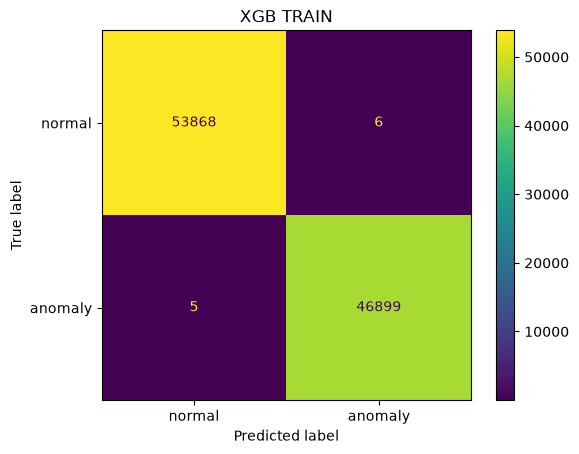

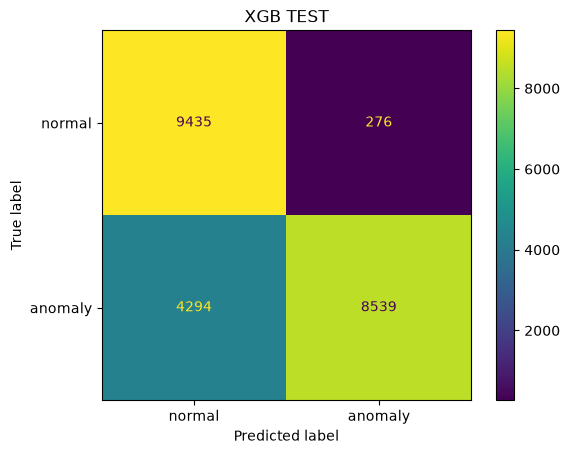

In [33]:
evaluate(xgb_model.predict(scaled_train_X), train_y, title="XGB TRAIN")
evaluate(xgb_model.predict(scaled_test_X), test_y, title="XGB TEST")